>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
from matplotlib.ticker import PercentFormatter 
from matplotlib.ticker import FormatStrFormatter
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *

In [2]:
# Enter variable and data type
variable = {"name": "comm_rate", "sym": "$\pi", "int": False}
# variable = {"name": "fare", "sym": "$f_\mathrm{km}$", "int": False}

In [3]:
# Plot input
plt.rcParams['figure.figsize'] = [4, 4]
plt.rcParams["font.family"] = "Times New Roman"
plt.style.use('ggplot')
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
font = {'family' : 'Times New Roman',
        'weight' : 'normal',
        'size'   : 13}
plt.rc('legend', fontsize=14) #14
plt.rcParams['legend.title_fontsize'] = 14 #16
plt.rc('font', **font)

In [5]:
# dir_name = os.getcwd()
dir_name = os.path.join(os.getcwd(),'input',variable["name"])
extension = ".zip"

var_val = []
res = DotMap()
pax_kpi = DotMap()
plf = DotMap()
params = DotMap()
driver_eql = DotMap()
trav_eql = DotMap()
run_id = 0
for item in os.listdir(dir_name): # loop through items in dir
    if item.endswith(extension): # check for ".zip" extension
#         zip_file_name = os.path.abspath(item) # get full path of files
#         print(item)
        zip_file_name = os.path.join(dir_name,item) # get full path of files
        zip_ref = zipfile.ZipFile(zip_file_name) # create zipfile object
        res.sup[run_id] = pd.read_csv(zip_ref.open('d2d_agg_supply.csv'),index_col=0)
        res.dem[run_id] = pd.read_csv(zip_ref.open('d2d_agg_demand.csv'),index_col=0)
        
        var_val.append(float(re.split('_|-', item)[3]))
#         var_val.append(float(re.split('_|-', item)[2]))
        
        for filename in zip_ref.namelist():
            if filename.startswith("params"):
                with zip_ref.open(filename) as f:
                    data = f.read()
                    params[run_id] = json.loads(data)
    
#             if filename.endswith("pax_kpi.csv"):
#                 day = int(filename.replace('day_','').replace('_pax_kpi.csv',''))
#                 pax_kpi[run_id][day] = pd.read_csv(zip_ref.open(filename),index_col=0)
                
#             if filename.endswith("veh_kpi.csv"):
#                 day = int(filename.replace('day_','').replace('_veh_kpi.csv',''))
#                 plf[run_id][day] = pd.read_csv(zip_ref.open(filename),index_col=0)
            
            if filename == "day_{}_vehicles.csv".format(params[run_id]['nD']-1):
                driver_eql[run_id] = pd.read_csv(zip_ref.open(filename),index_col=0)
                
            if filename == "day_{}_veh_exp.csv".format(params[run_id]['nD']-1):
                veh_exp = pd.read_csv(zip_ref.open(filename),index_col=0)
                xp_income = veh_exp.loc[veh_exp.OUT == False].NET_INCOME
                driver_eql[run_id]['experienced_income'] = np.nan
                driver_eql[run_id].loc[driver_eql[run_id].event == "driverEvent.ENDS_SHIFT", ['experienced_income']] = xp_income
                
            if filename == "day_{}_passengers.csv".format(params[run_id]['nD']-1):
                trav_eql[run_id] = pd.read_csv(zip_ref.open(filename),index_col=0)
                
            if filename == "day_{}_pax_exp.csv".format(params[run_id]['nD']-1):
                pax_exp = pd.read_csv(zip_ref.open(filename),index_col=0)
                xp_wait = pax_exp.loc[pax_exp.OTHER_MODE == False].WAIT
                pax_exp['corr_xp_wait'] = xp_wait.copy()
                pax_exp.loc[((~pax_exp.NO_REQUEST) & (~pax_exp['LOSES_PATIENCE'].apply(lambda x: True if x == 0 else False))),['corr_xp_wait']] = params[run_id]['evol']['travellers']['reject_penalty']
                trav_eql[run_id]['experienced_wait'] = np.nan
                trav_eql[run_id].loc[trav_eql[run_id].mode_day == 'rs', ['experienced_wait']] = xp_wait
                trav_eql[run_id]['corr_experienced_wait'] = np.nan
                trav_eql[run_id].loc[trav_eql[run_id].mode_day == 'rs', ['corr_experienced_wait']] = pax_exp.corr_xp_wait
                
        zip_ref.close() # close file
        run_id += 1

In [6]:
# Add all days to a single dataframe with days as rows
# d2d_pax = DotMap()
d2d_plf = DotMap()
for run_id in range(len(params)):
#     wait_time_list = list()
#     pax_reject_list = list()
    plf_prof_list = list()
    for day in range(len(params[run_id]['nD'])):
#         wait_time_list.append(pax_kpi[run_id][day].MEETS_DRIVER_AT_PICKUP.loc['mean'])
#         pax_reject_list.append((pax_kpi[run_id][day].LOSES_PATIENCE.loc['sum'] / (params[run_id]['times']['request'] + params[run_id]['times']['patience']))/params[run_id]['nP'])
        plf_prof_list.append(plf[run_id][day].REVENUE.loc['sum'] * (1 / (1-params[run_id]['platforms']['comm_rate'])) * params[run_id]['platforms']['comm_rate'])
#     d2d_dict = {'wait_time': wait_time_list, 'pax_reject': pax_reject_list }
#     d2d_pax[run_id] = pd.DataFrame(d2d_dict)
#     d2d_pax[run_id].index.name = 'day'
    d2d_plf[run_id] = pd.DataFrame(plf_prof_list)
    d2d_plf[run_id].index.name = 'day'

In [7]:
# Find equilibrium values for all runs
res_list = list()
for repl_id in range(0,len(res.sup)):
    params[repl_id]['conv_max_error'] = 0.01
    params[repl_id]['conv_signif'] = 0.01
    params[repl_id]['conv_day'] = 3 # X days in a row a change in perceived income below the convergence factor
    params[repl_id]['conv_factor'] = 0.0025
    conv_sup = D2D_conv(perc = res.sup[repl_id].mean_perc_inc, params = params[repl_id])
    conv_dem = D2D_conv(perc = res.dem[repl_id].perc_wait, params = params[repl_id])
    t_conv = max(conv_sup[0],conv_dem[0])
    conv_sys = conv_sup + conv_dem + [t_conv]                 
    res_list.append(conv_sys)
conv_repl = pd.DataFrame(res_list,columns = ['t_sup*', 'perc_inc*', 't_dem*', 'perc_wait', 't*'])
conv_repl['converged'] = (conv_repl['t*'] < params[0]['nD']-1)
if not conv_repl.converged.all():
    print('WARNING: not all replications have converged')

conv_repl.head(5)

,t_sup*,perc_inc*,t_dem*,perc_wait,t*,converged
0,58,125.730777,27,188.295661,58,True
1,58,125.109524,79,141.870557,79,True
2,108,125.551677,78,140.483436,108,True
3,81,123.553539,79,141.086206,81,True
4,30,130.807957,25,189.055502,30,True


In [8]:
# Create DataFrame with scenarios
scn = pd.DataFrame(var_val, columns = ['val'])
vals = scn.val.unique()
if variable["int"]:
    vals = list(map(int, vals))
vals = sorted(vals)

In [9]:
scn_map = DotMap()
d2d = DotMap()
res_scn = DotMap()
res_scn_std = DotMap()
params_scn = DotMap()
# kpis = res[0].columns
kpis = ["informed_drivers", "regist_drivers", "particip_drivers", "mean_perc_inc", "mean_exp_inc", "informed_travs", "requests", "mean_wait_time", "exp_wait_time", "exp_pure_wait", "gets_offer", "plf_profit"]

for i in vals:
    # Determine which replications are part of the scenario and save params
    run_ids = scn[scn['val'] == i].index
    params_scn[i] = params[run_ids[0]]
    
    # Check number of replications needed
    conv = conv_repl.loc[run_ids]
    t_conv_all = conv['t*'].max()
    t_conv_all = int(math.ceil(t_conv_all / 10.0)) * 10
    if t_conv_all >= params_scn[i]['nD']:
        t_conv_all = params_scn[i]['nD'] - 1
    conv_perc_inc = [res.sup[run_id].mean_perc_inc[t_conv_all] for run_id in run_ids]
    conv_perc_wait = [res.dem[run_id].mean_wait[t_conv_all] for run_id in run_ids]
    
    repl_req_sup = repl_num(perc = conv_perc_inc, params = params_scn[i])
    repl_req_dem = repl_num(perc = conv_perc_wait, params = params_scn[i])
    repl_req_sys = max(repl_req_sup, repl_req_dem)
    
    
    if repl_req_sys > params_scn[i]['nReplications']:
        print("WARNING: insufficient number of replications: {}/{}".format(params_scn[i]['nReplications'],math.ceil(repl_req_sys)))
    
    # Create dataframes for each scenario
    for kpi in kpis:
        d2d[i][kpi] = empty_df(params = params)
        
    conv = list()
    for k in range(len(run_ids)):
        # Replication within scenario
        run_id = run_ids[k]
        
        scn_map[i][k] = res[run_id]
        
        d2d[i].informed_drivers[k] = res.sup[run_id].inform
        d2d[i].regist_drivers[k] = res.sup[run_id].regist
        d2d[i].particip_drivers[k] = res.sup[run_id].particip
        d2d[i].mean_perc_inc[k] = res.sup[run_id].mean_perc_inc
        d2d[i].mean_exp_inc[k] = res.sup[run_id].mean_exp_inc
        
        d2d[i].informed_travs[k] = res.dem[run_id].inform
        d2d[i].requests[k] = res.dem[run_id].requests
        d2d[i].mean_wait_time[k] = res.dem[run_id].perc_wait
        d2d[i].exp_wait_time[k] = res.dem[run_id].corr_mean_wait
        d2d[i].exp_pure_wait[k] = res.dem[run_id].mean_wait
        d2d[i].gets_offer[k] = res.dem[run_id].gets_offer
        d2d[i].plf_profit[k] = d2d_plf[run_id]
        
    # Add mean value and st dev of different replications for a single scenario
    for kpi in kpis:
        d2d[i][kpi]['mean'] = d2d[i][kpi].mean(axis=1)
        d2d[i][kpi]['stdev'] = d2d[i][kpi].loc[:, d2d[i][kpi].columns != 'mean'].std(axis=1)
    
# Create new df with aggregated result for all scenarios
for kpi in kpis:
    res_scn[kpi] = join_scn_df(d2d,vals,kpi)
        

In [10]:
# res_list = list()
# for i in range(0,len(res)):
#     params[repl_id].conv.day = 3 # X days in a row a change in perceived income below the convergence factor
#     params[repl_id].conv.factor = 0.001
#     res_list.append(D2D_conv(res_repl = res[i], params = params[repl_id]))
# conv_repl = pd.DataFrame(res_list,columns = ['t*', 'perc_inc*'])
# t_conv_all = conv_repl['t*'].max()
# t_conv_all = int(math.ceil(t_conv_all / 10.0)) * 10
# res_list

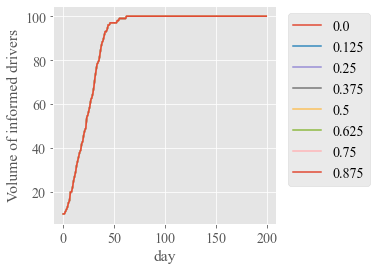

In [11]:
# Plot number of informed drivers
plot_inform = res_scn.informed_drivers.plot()
plot_inform.set_ylabel("Volume of informed drivers")
# plot_regist.legend(['Registered','Participating'])
plot_inform
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

<AxesSubplot:xlabel='day', ylabel='Registration volume'>

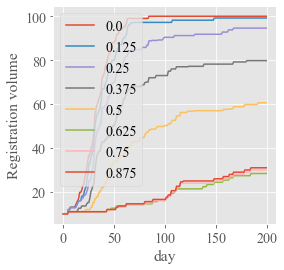

In [12]:
# Plot number of registered drivers
plot_regist = res_scn.regist_drivers.plot()
plot_regist.set_ylabel("Registration volume")
# plot_regist.legend(['Registered','Participating'])
plot_regist

<AxesSubplot:xlabel='day', ylabel='Participation volume'>

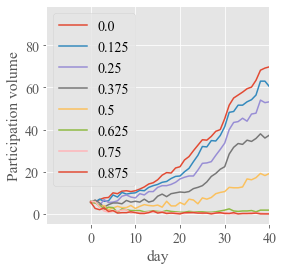

In [13]:
# Plot number of participating drivers
plot_ptcp = res_scn.particip_drivers.plot()
plot_ptcp.set_ylabel("Participation volume")
plot_ptcp.set_xlim(right = 40)
# plot_regist.legend(['Registered','Participating'])
plot_ptcp

<AxesSubplot:xlabel='day', ylabel='Relative participation'>

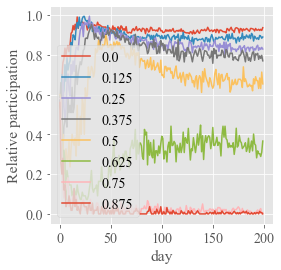

In [14]:
plot_ptcp_rel = (res_scn.particip_drivers / res_scn.regist_drivers).plot()
plot_ptcp_rel.set_ylabel("Relative participation")
# plot_regist.legend(['Registered','Participating'])
plot_ptcp_rel

<AxesSubplot:xlabel='day', ylabel='Mean expected income'>

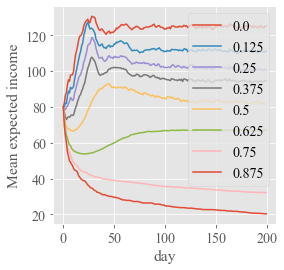

In [15]:
# Plot mean expected income
plot_perc_inc = res_scn.mean_perc_inc.plot()
plot_perc_inc.set_ylabel("Mean expected income")
# plot_regist.legend(['Registered','Participating'])
# plot_perc_inc.set_xlim(right = 40)
plot_perc_inc

# fig, axes = plt.subplots(nrows=1, ncols=2)
# res_scn.mean_perc_inc.plot(ax=axes[0])
# res_scn.mean_perc_inc.plot(ax=axes[1])

# ax1.plot(res_scn.mean_perc_inc)
# ax2.plot(res_scn.mean_perc_inc)

DotMap(_ipython_display_=DotMap(), _repr_mimebundle_=DotMap())

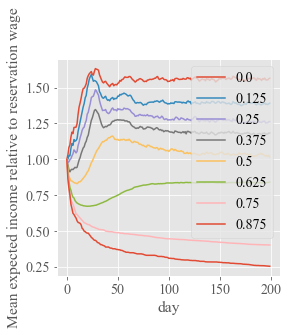

In [16]:
# Plot mean expected income as ratio of reservation wage
res_scn['mean_perc_inc_rel'] = pd.DataFrame()
for i in vals:
    res_scn['mean_perc_inc_rel'][i] = res_scn.mean_perc_inc[i] / params_scn[i]['evol']['drivers']['res_wage']['mean']
res_scn.mean_perc_inc_rel = res_scn.mean_perc_inc_rel.reindex(sorted(res_scn.mean_perc_inc_rel.columns), axis=1)
plot_perc_inc_rel = res_scn.mean_perc_inc_rel.plot()
plot_perc_inc_rel.set_ylabel("Mean expected income relative to reservation wage")
# plot_regist.legend(['Registered','Participating'])
# plot_perc_inc_rel

# fig, axes = plt.subplots(nrows=1, ncols=2)
# res_scn.mean_perc_inc.plot(ax=axes[0])
# res_scn.mean_perc_inc.plot(ax=axes[1])

# ax1.plot(res_scn.mean_perc_inc)
# ax2.plot(res_scn.mean_perc_inc)
res_scn.mean_per_inc_rel

,0.000,0.125,0.250,0.375,0.500,0.625,0.750,0.875
day,,,,,,,,
0,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000
1,0.779296,0.750115,0.729186,0.713649,0.680433,0.666066,0.636221,0.615953
2,0.831717,0.776204,0.731476,0.676201,0.629720,0.598741,0.535746,0.550706
3,0.850184,0.774104,0.747558,0.661944,0.616709,0.553163,0.483735,0.503319
4,0.903875,0.826279,0.754021,0.675106,0.598984,0.532730,0.460764,0.436418


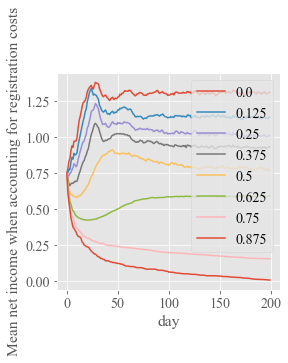

In [17]:
res_scn['net_perc_inc'] = pd.DataFrame()
for i in vals:
    res_scn['net_perc_inc'][i] = (res_scn.mean_perc_inc[i] - params_scn[i]['evol']['drivers']['regist']['cost_comp']) / params_scn[i]['evol']['drivers']['res_wage']['mean']
res_scn.net_perc_inc = res_scn.net_perc_inc.reindex(sorted(res_scn.net_perc_inc.columns), axis=1)
plot_net_perc_inc = res_scn.net_perc_inc.plot()
plot_net_perc_inc.set_ylabel("Mean net income when accounting for registration costs")
# plot_regist.legend(['Registered','Participating'])
# plot_perc_inc_rel

# fig, axes = plt.subplots(nrows=1, ncols=2)
# res_scn.mean_perc_inc.plot(ax=axes[0])
# res_scn.mean_perc_inc.plot(ax=axes[1])

# ax1.plot(res_scn.mean_perc_inc)
# ax2.plot(res_scn.mean_perc_inc)
res_scn.net_perc_inc.head(5)

In [18]:
# Distribution of expected and experienced income and waiting time in equilibrium (i.e. day 200) across drivers
eql_scn_sup = DotMap()
eql_scn_reg = DotMap()
eql_scn_ptcp = DotMap()
eql_scn_dem = DotMap()
std_perc_inc = pd.DataFrame()
std_exp_inc = pd.DataFrame()
std_perc_wait = pd.DataFrame()
std_exp_wait = pd.DataFrame()
std_corr_exp_wait = pd.DataFrame()

for i in range(len(vals)):
    # Determine which replications are part of the scenario
    temp_list_perc_inc = []
    temp_list_exp_inc = []
    temp_list_perc_wait = []
    temp_list_exp_wait = []
    temp_list_corr_exp_wait = []
    run_ids = scn[scn['val'] == vals[i]].index

    eql_scn_sup[i] = pd.DataFrame(columns= driver_eql[0].columns)
    eql_scn_dem[i] = pd.DataFrame(columns= trav_eql[0].columns)
    
    for k in run_ids:
        eql_scn_sup[i] = pd.concat([eql_scn_sup[i],driver_eql[k]])
        eql_scn_dem[i] = pd.concat([eql_scn_dem[i],trav_eql[k]])
        temp_list_perc_inc.append(driver_eql[k].expected_income.std())
        temp_list_exp_inc.append(driver_eql[k].experienced_income.std())
        temp_list_perc_wait.append(trav_eql[k].expected_wait.std())
        temp_list_exp_wait.append(trav_eql[k].experienced_wait.std())
        temp_list_corr_exp_wait.append(trav_eql[k].corr_experienced_wait.std())
        
    eql_scn_reg[i] = eql_scn_sup[i][eql_scn_sup[i].expected_income.notnull()]
    eql_scn_ptcp[i] = eql_scn_sup[i][eql_scn_sup[i].event == 'driverEvent.ENDS_SHIFT']
    std_perc_inc[vals[i]] = temp_list_perc_inc
    std_exp_inc[vals[i]] = temp_list_exp_inc
    std_perc_wait[vals[i]] = temp_list_perc_wait
    std_exp_wait[vals[i]] = temp_list_exp_wait
    std_corr_exp_wait[vals[i]] = temp_list_corr_exp_wait

std_perc_inc = std_perc_inc.mean()
std_exp_inc = std_exp_inc.mean()
std_perc_wait = std_perc_wait.mean()
std_exp_wait = std_exp_wait.mean()
std_corr_exp_wait = std_corr_exp_wait.mean()

In [19]:
driver_eql[0]

,pos,event,shift_start,shift_end,platform,expected_income,res_wage,informed,registered,experienced_income
veh,,,,,,,,,,
1,4.655079e+07,driverEvent.ENDS_SHIFT,0,86400,0,128.340097,86.762063,True,True,83.0225
2,4.638074e+07,driverEvent.ENDS_SHIFT,0,86400,0,116.328553,72.818101,True,True,148.8050
3,4.635439e+07,driverEvent.ENDS_SHIFT,0,86400,0,138.643080,56.292601,True,True,159.0625
4,7.887656e+09,driverEvent.ENDS_SHIFT,0,86400,0,126.022334,77.283196,True,True,199.2100
5,4.657337e+07,driverEvent.ENDS_SHIFT,0,86400,0,119.911948,86.434369,True,True,102.7625
...,...,...,...,...,...,...,...,...,...,...
96,3.820400e+08,driverEvent.ENDS_SHIFT,0,86400,0,115.087792,93.307356,True,True,99.9500
97,4.645525e+07,driverEvent.ENDS_SHIFT,0,86400,0,142.651192,81.148970,True,True,100.5800
98,5.410209e+09,driverEvent.ENDS_SHIFT,0,86400,0,132.132416,92.640309,True,True,143.4575


In [20]:
eql_scn_reg[0].head(5)

,pos,event,shift_start,shift_end,platform,expected_income,res_wage,informed,registered,experienced_income
1,4.655079e+07,driverEvent.ENDS_SHIFT,0,86400,0,128.340097,86.762063,True,True,83.0225
2,4.638074e+07,driverEvent.ENDS_SHIFT,0,86400,0,116.328553,72.818101,True,True,148.8050
3,4.635439e+07,driverEvent.ENDS_SHIFT,0,86400,0,138.643080,56.292601,True,True,159.0625
4,7.887656e+09,driverEvent.ENDS_SHIFT,0,86400,0,126.022334,77.283196,True,True,199.2100
5,4.657337e+07,driverEvent.ENDS_SHIFT,0,86400,0,119.911948,86.434369,True,True,102.7625


In [21]:
std_perc_inc

0.000    23.306199
0.125    19.351955
0.250    15.380928
0.375    10.307301
0.500     2.977009
0.625     1.660879
0.750     4.461047
0.875     8.478662
dtype: float64

In [22]:
# # Plot distribution for a single scenario
# scen = 2
# weights = np.ones_like(eql_scn[scen].expected_income) / (len(eql_scn[scen].expected_income))
# # plot_distr_exp_inc = eql_scn[scn].expected_income[scn]
# # plt.hist(eql_scn[scen].expected_income,bins=range(0,int(math.ceil(eql_scn[scen].expected_income.max() / 5.0)) * 5,5),weights=weights)
# plt.hist(eql_scn[scen].expected_income,bins=range(0,int(math.ceil(eql_scn[scen].expected_income.max() / 5.0)) * 5,5))
# plt.hist((eql_scn[scen][eql_scn[scen].event != "driverEvent.DECIDES_NOT_TO_DRIVE"]).expected_income,bins=range(0,int(math.ceil(eql_scn[scen].expected_income.max() / 5.0)) * 5,5))
# plt.axvline(x=params[0]['drivers']['reservation_wage'],color='grey',linestyle='--')

In [23]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize = [8,4], sharey = False)
# # fig.subplots_adjust(hspace=0.45, wspace=0.35)
# for scen in range(len(vals)):
# #     eql_scn_reg[scen]['rel_perc_inc'] = eql_scn_reg[scen].expected_income / params_scn[vals[scen]]['drivers']['reservation_wage']
#     # particip_drivers = eql_scn[scen][eql_scn[scen].event != "driverEvent.DECIDES_NOT_TO_DRIVE"]
#     plot_dens = eql_scn_reg[scen].expected_income.plot(kind='density',ax=axes[0])
#     plot_dens2 = eql_scn_ptcp[scen].expected_income.plot(kind='density',ax=axes[1])    
#     # plot_part = particip_drivers.expected_income.plot(kind='density')
#     # plot_dens.set_xlim(0,math.ceil(eql_scn[scen].expected_income.max() / 25.0) * 25)
# fig.figsize = [4,8]
# plot_dens.set_xlabel('Expected income (€)') 
# plot_dens.set_xlim(40,120)
# plot_dens.set_ylim(0,0.1)
# plot_dens.set_title('Registered',fontsize=14)

# plot_dens2.set_xlim(40,120)
# plot_dens2.set_ylim(0,0.1)
# # plot_dens2.set_ylim(0,0.1/(len(eql_scn_ptcp[0].index)/len(eql_scn_reg[0].index)))
# plot_dens2.set_xlabel('Expected income (€)')
# plot_dens2.set_title('Participating',fontsize=14)
# plot_dens.legend(vals, loc='right',bbox_to_anchor=(2.7, 0.5))
# plot_dens.axvline(x=params_scn[vals[scen]]['evol']['drivers']['res_wage']['mean'],color='grey',linestyle='--')
# plot_dens2.axvline(x=params_scn[vals[scen]]['evol']['drivers']['res_wage']['mean'],color='grey',linestyle='--')

<AxesSubplot:xlabel='day', ylabel='Informed travellers'>

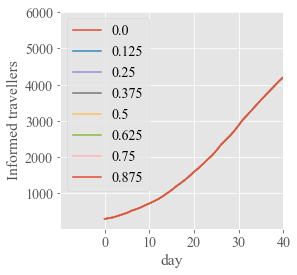

In [24]:
# Plot number of participating drivers
plot_inf_trav = res_scn.informed_travs.plot()
plot_inf_trav.set_ylabel("Informed travellers")
plot_inf_trav.set_xlim(right = 40)
# plot_regist.legend(['Registered','Participating'])
plot_inf_trav

<AxesSubplot:xlabel='day', ylabel='RS requests'>

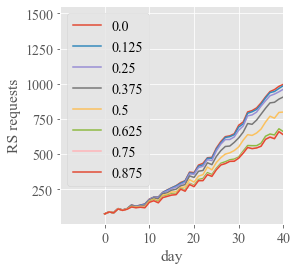

In [25]:
# Plot mode choice over time
plot_mode = res_scn.requests.plot()
plot_mode.set_ylabel("RS requests")
plot_mode.set_xlim(right = 40)
# plot_regist.legend(['Registered','Participating'])
plot_mode

<AxesSubplot:xlabel='day', ylabel='Experienced waiting time'>

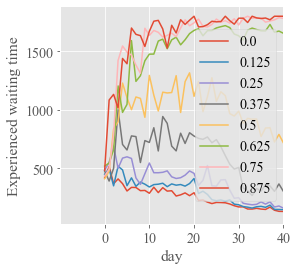

In [26]:
# Plot exp. waiting time
plot_mode = res_scn.exp_wait_time.plot()
plot_mode.set_ylabel("Experienced waiting time")
plot_mode.set_xlim(right = 40)
# plot_regist.legend(['Registered','Participating'])
plot_mode

In [27]:
if variable['name']== 'het_res_wage':
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize = [8,4], sharey = False)
    # fig.subplots_adjust(hspace=0.45, wspace=0.35)
    for scen in range(len(vals)):
    #     eql_scn_reg[scen]['rel_perc_inc'] = eql_scn_reg[scen].expected_income / params_scn[vals[scen]]['drivers']['reservation_wage']
        # particip_drivers = eql_scn[scen][eql_scn[scen].event != "driverEvent.DECIDES_NOT_TO_DRIVE"]
        plot_dens = eql_scn_reg[scen].res_wage.plot(kind='density',ax=axes[0])
        plot_dens2 = eql_scn_ptcp[scen].res_wage.plot(kind='density',ax=axes[1])    
        # plot_part = particip_drivers.expected_income.plot(kind='density')
        # plot_dens.set_xlim(0,math.ceil(eql_scn[scen].expected_income.max() / 25.0) * 25)
    fig.figsize = [4,8]
    plot_dens.set_xlabel('Expected income (€)') 
    plot_dens.set_xlim(0,120)
    plot_dens.set_ylim(0,0.1)
    plot_dens.set_title('Registered',fontsize=14)

    plot_dens2.set_xlim(0,120)
    plot_dens2.set_ylim(0,0.1)
    # plot_dens2.set_ylim(0,0.1/(len(eql_scn_ptcp[0].index)/len(eql_scn_reg[0].index)))
    plot_dens2.set_xlabel('Expected income (€)')
    plot_dens2.set_title('Participating',fontsize=14)
    plot_dens.legend(vals, loc='right',bbox_to_anchor=(2.7, 0.5))
    plot_dens.axvline(x=params_scn[vals[scen]]['drivers']['reservation_wage'],color='grey',linestyle='--')
    plot_dens2.axvline(x=params_scn[vals[scen]]['drivers']['reservation_wage'],color='grey',linestyle='--')

In [28]:
eql_scn_reg[0].expected_income.head(5)

1    128.340097
2    116.328553
3    138.643080
4    126.022334
5    119.911948
Name: expected_income, dtype: float64

In [29]:
res_class = DotMap()
if variable["name"] == 'ptcp_beta':
    for i in range(len(vals)):
        df = eql_scn_reg[i].copy()
        # Create new df based on classes
        bins = np.arange(50,110,5)
        df["exp_inc_group"] = pd.cut(df.expected_income,bins)
        ptcp = {'driverEvent.DECIDES_NOT_TO_DRIVE': int(0), 'driverEvent.ENDS_SHIFT': int(1)}
        df['participate'] = df['event'].map(ptcp)
        df["informed"] = df["informed"].astype(int)
        df["registered"] = df["registered"].astype(int)
        res_class[i] = df.groupby('exp_inc_group').mean()
#         ax2 = res_class.plot.bar(y=['registered','participate'])
    res_class[0]

    class_df = pd.DataFrame(index = res_class[0].index)
    for i in range(len(vals)):
        class_df[vals[i]] = res_class[i].participate
    ax = class_df.plot.bar(width=0.8)
    ax.set_xlabel('Expected income (€)')

In [30]:
res_class = DotMap()
res_df = pd.DataFrame()
bins = np.arange(20,140,10)
if variable["name"] == 'het_res_wage':
#     extr_scen = max(vals) # Find extreme scenario for analysis
#     scen = vals.index(extr_scen) # find the corresponding scenario

    for scen_id in range(1,len(vals)):
#         scen = 2
        df = eql_scn[scen_id]
#     ax1 = df.plot.scatter(x='res_wage',
#                       y='expected_income',
#                       c='DarkBlue')
        
        df["res_wage_group"] = pd.cut(df.res_wage,bins=bins)
        ptcp = {'driverEvent.DECIDES_NOT_TO_DRIVE': int(0), 'driverEvent.ENDS_SHIFT': int(1)}
        df['participate'] = df['event'].map(ptcp)
        df["informed"] = df["informed"].astype(int)
        df["registered"] = df["registered"].astype(int)
        res_class[scen_id] = df.groupby('res_wage_group').mean()
        ax2 = res_class[scen_id].plot.bar(y=['registered','participate'])
        res_df[vals[scen_id]]=res_class[scen_id].registered.copy()
    res_class
    res_df.plot.bar()

In [31]:
# plot_perc_inc_scn = res_scn.mean_perc_inc.iloc[params[0]['nD']-1].plot()
# plot_perc_inc_scn.set_ylabel("Mean expected income")
# # plot_regist.legend(['Registered','Participating'])
# # plot_perc_inc_scn

<AxesSubplot:xlabel='day', ylabel='Mean experienced income'>

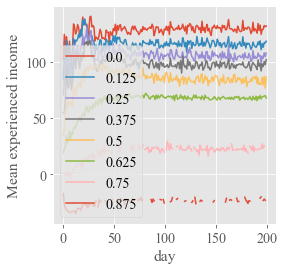

In [32]:
# Plot experienced income
res_scn['mean_exp_inc_rel'] = pd.DataFrame()
res_scn['mean_exp_inc_rel_net'] = pd.DataFrame()
for i in vals:
    res_scn['mean_exp_inc_rel'][i] = res_scn.mean_exp_inc[i] / params_scn[i]['evol']['drivers']['res_wage']['mean']
    res_scn['mean_exp_inc_rel_net'][i] = res_scn.mean_exp_inc[i] / (params_scn[i]['evol']['drivers']['res_wage']['mean'] + params_scn[i]['evol']['drivers']['regist']['cost_comp'])
res_scn.mean_exp_inc_rel = res_scn.mean_exp_inc_rel.reindex(sorted(res_scn.mean_exp_inc_rel.columns), axis=1)
res_scn.mean_exp_inc_rel_net = res_scn.mean_exp_inc_rel_net.reindex(sorted(res_scn.mean_exp_inc_rel_net.columns), axis=1)
plot_exp_inc = res_scn.mean_exp_inc.plot()
plot_exp_inc.set_ylabel("Mean experienced income")
# plot_regist.legend(['Registered','Participating'])
plot_exp_inc

<AxesSubplot:xlabel='day', ylabel='Mean passenger waiting time (s)'>

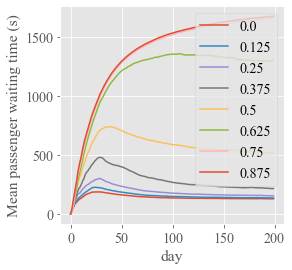

In [33]:
# Plot waiting time
plot_wait_time = res_scn.mean_wait_time.plot()
plot_wait_time.set_ylabel("Mean passenger waiting time (s)")
# plot_regist.legend(['Registered','Participating'])
plot_wait_time

<AxesSubplot:xlabel='day', ylabel='Service rate'>

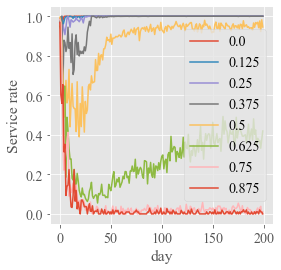

In [34]:
# Plot percentage of rejected requests
plot_reject = (res_scn.gets_offer / res_scn.requests).plot()
plot_reject.set_ylabel("Service rate")
# plot_regist.legend(['Registered','Participating'])
plot_reject

<AxesSubplot:xlabel='day', ylabel='Platform profit'>

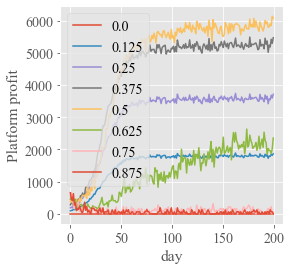

In [35]:
# Plot evolution of platform profit
plot_plf_profit = res_scn.plf_profit.plot()
plot_plf_profit.set_ylabel("Platform profit")
# plot_regist.legend(['Registered','Participating'])
plot_plf_profit



In [36]:
# plot_plf_profit_scn = res_scn.plf_profit.iloc[params[0]['nD']-1].plot()
# plot_plf_profit_cum = (res_scn.plf_profit.sum()).plot()
# plot_plf_profit_scn
# plot_plf_profit_cum

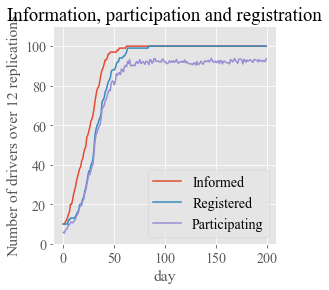

In [37]:
# Choose a single scenario
scen = 0
plt.plot(res_scn.informed_drivers[vals[scen]])
plt.plot(res_scn.regist_drivers[vals[scen]])
plt.plot(res_scn.particip_drivers[vals[scen]])
# plt.errorbar(res_scn.index,res_scn.regist.mean,res_scn.regist.std)
# plt.errorbar(overall.index,overall.particip_mean,overall.particip_std)
plt.xlabel('day')
plt.ylabel('Number of drivers over 12 replications')
plt.title('Information, participation and registration')
plt.legend(["Informed","Registered", "Participating"])
plt.ylim(0,params[0]['nV']*1.1)
plt.show()

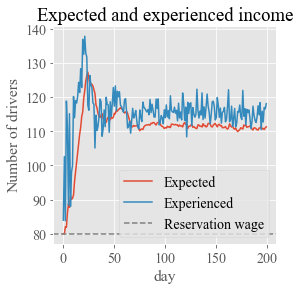

In [38]:
# Choose a single scenario
scen = 1
scn_ids = scn[scn['val'] == vals[scen]].index
scn_id = scn_ids[0]
plt.plot(res_scn.mean_perc_inc[vals[scen]])
plt.plot(res_scn.mean_exp_inc[vals[scen]])
plt.axhline(y=params[scn_id]['evol']['drivers']['res_wage']['mean'],color='gray',linestyle='--')
# plt.errorbar(res_scn.index,res_scn.regist.mean,res_scn.regist.std)
# plt.errorbar(overall.index,overall.particip_mean,overall.particip_std)
plt.xlabel('day')
plt.ylabel('Number of drivers')
plt.title('Expected and experienced income')
plt.legend(["Expected","Experienced","Reservation wage"])
# plt.ylim(0,params[0]['nV']*1.1)
plt.show()

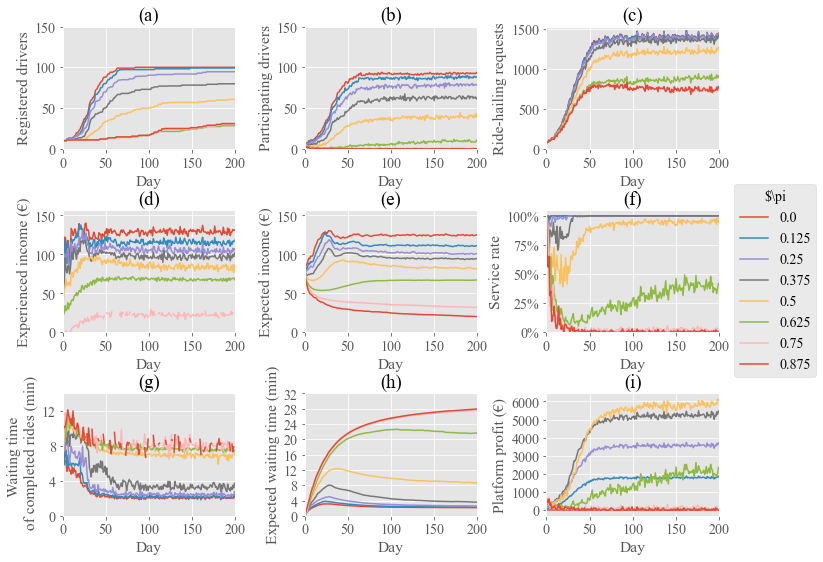

In [39]:
# Creates four polar axes, and accesses them through the returned array
fig, axes = plt.subplots(3, 3, figsize = [12,9])
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.45, left=.14, right=.86, wspace=0.4)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# plt.setp(axes, xlim=[0,200])
# axes[0, 0].plot(res_scn.informed_drivers)
# # axes[0, 0].set_title()
# axes[0, 0].set_ylabel('Informed agents')
# axes[0, 0].set_xlabel('Day')
# axes[0, 0].set_title('(a)')
# axes[0, 0].set_ylim(bottom = 0, top = res_scn.informed_drivers.max().max() + 25)
# axes[0, 0].locator_params(axis='y', nbins=5)

plt.setp(axes, xlim=[0,200])
axes[0, 2].plot(res_scn.requests)
# axes[0, 0].set_title()
axes[0, 2].set_ylabel('Ride-hailing requests')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = 0, top = res_scn.requests.max().max() + 50)
# axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.requests.max().max()*1.2/50)*50+100)
axes[0, 2].locator_params(axis='y', nbins=5)

axes[0, 0].plot(res_scn.regist_drivers)
# axes[0, 0].set_title()
axes[0, 0].set_ylabel('Registered drivers')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.regist_drivers.max().max()/100)*100+50)
axes[0, 0].set_xlim(left = 0, right = 200)
axes[0, 0].locator_params(axis='y', nbins=5)
# axes[0, 0].plot(res_scn.informed_drivers)
# axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 1].plot(res_scn.particip_drivers)
axes[0, 1].set_ylabel('Participating drivers')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.particip_drivers.max().max()/100)*100+50)
axes[0, 1].set_xlim(left = 0, right = 200)
axes[0, 1].locator_params(axis='y', nbins=5)

# axes[1, 2].plot((res_scn.particip / res_scn.regist))
# axes[1, 2].set_ylabel('Participation rate')
# axes[1, 2].set_xlabel('Day')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# axes[1, 2].set_title('(f)')
# axes[1, 2].set_xlim(left = 0, right = 200)
# axes[1, 2].set_ylim(bottom = 0)
# axes[1, 2].locator_params(axis='y', nbins=5)

# axes[1, 0].plot((res_scn.mean_exp_inc_rel))
# axes[1, 0].set_ylabel('Rel. experienced inc.')
# axes[1, 0].set_xlabel('Day')
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel.max().max()*1.1/0.5)*0.5)
# axes[1, 0].locator_params(axis='y', nbins=5)
# axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# axes[1, 1].plot((res_scn.mean_exp_inc_rel_net))
# axes[1, 1].set_ylabel('Net rel. experienced inc.')
# axes[1, 1].set_xlabel('Day')
# axes[1, 1].set_title('(e)')
# axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel_net.max().max()*1.1/0.5)*0.5)
# axes[1, 1].locator_params(axis='y', nbins=5)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# axes[1, 2].plot((res_scn.mean_perc_inc))
# axes[1, 2].set_ylabel('Expected income')
# axes[1, 2].set_xlabel('day')
# axes[1, 2].set_title('(f)')

axes[2, 2].plot(res_scn.plf_profit)
axes[2, 2].set_ylabel('Platform profit (€)')
axes[2, 2].set_xlabel('Day')
axes[2, 2].set_xlim(left = 0, right = 200)
# axes[2, 2].set_ylim(bottom = 0)
axes[2, 2].set_title('(i)')
axes[2, 2].set_yticks(np.arange(0, math.ceil((res_scn.plf_profit).max().max()*1.1/1)*1+200, step=1000))

# axes[1, 2].plot((res_scn.regist / res_scn.inform))
# axes[1, 2].set_ylabel('Informed drivers \n with registration')
# axes[1, 2].set_xlabel('day')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# axes[1, 2].set_title('(f)')

axes[2, 1].plot((res_scn.mean_wait_time/60))
axes[2, 1].set_ylabel('Expected waiting time (min)')
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_title('(h)')
axes[2, 1].set_ylim(bottom = 0, top = math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1)
axes[2, 1].set_yticks(np.arange(0, math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1+2, step=4))
axes[2, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

axes[2, 0].plot((res_scn.exp_pure_wait/60))
axes[2, 0].set_ylabel('Waiting time \n of completed rides (min)')
axes[2, 0].set_xlabel('Day')
axes[2, 0].set_title('(g)')
axes[2, 0].set_ylim(bottom = 0, top = math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1)
axes[2, 0].set_yticks(np.arange(0, math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1+0, step=4))
axes[2, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# axes[0, 2].plot(res_scn.mean_perc_inc_rel)
# axes[0, 2].set_ylabel('Rel. expected income')
# axes[0, 2].set_xlabel('Day')
# axes[0, 2].set_title('(c)')
# axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc_rel.max().max()*1.1/0.5)*0.5)
# axes[0, 2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 1].plot(res_scn.mean_perc_inc)
axes[1, 1].set_ylabel('Expected income (€)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('(e)')
axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 0].plot(res_scn.mean_exp_inc)
axes[1, 0].set_ylabel('Experienced income (€)')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('(d)')
axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[1, 0].locator_params(axis='y', nbins=4)

axes[1, 2].plot(res_scn.gets_offer / res_scn.requests)
axes[1, 2].set_ylabel('Service rate')
axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))  
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_title('(f)')
axes[1, 2].set_ylim(bottom = 0)
axes[1, 2].locator_params(axis='y', nbins=5)

# for scen in range(len(vals)):
#     axes[0, 2].hist(eql_scn_reg[scen].expected_income,bins = 100,density=True,alpha=0.3)
#     axes[0, 2].set_ylabel('Prob. density')
#     axes[0, 2].set_xlabel('Exp. income in equilibrium (€)')
#     axes[0, 2].set_title('(c)')
# #     axes[0, 2] = eql_scn_reg[scen].expected_income.plot(kind='density')
#     # plot_dens.set_xlim(0,math.ceil(eql_scn[scen].expected_income.max() / 25.0) * 25)
# axes[0, 2].set_xlim(0,150)

# axes[0, 2].plot(eql_scn_reg[scen].expected_income.plot(kind='density')
# axes[0, 2].set_ylabel('Expected income')
# axes[0, 2].set_xlabel('day')
# axes[0, 2].set_title('(c)')

# for i in range(len(vals)):
#     eql_scn_reg[i]['rel_perc_inc'] = eql_scn_reg[i].expected_income / params_scn[vals[i]]['drivers']['reservation_wage']
#     plot_dens = (eql_scn_reg[i].rel_perc_inc.plot(kind='density',ax=axes[0,1]))
# axes[0, 1].set_xlim(0.5,1.5)
# axes[0, 1].set_ylim(0, 8)
# # plt.locator_params(nbins=10)
# axes[0, 1].set_title('(b)')
# axes[0, 1].set_ylabel('Probability density')
# axes[0, 1].set_xlabel('Expected income / res. wage')

# for i in range(len(vals)):
#     plot_dens = (eql_scn_reg[i].res_wage.plot(kind='density',ax=axes[1,0]))
# axes[1, 0].set_xlim(0,120)
# axes[1, 0].set_ylim(0,0.06)
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylabel('Probability density')
# axes[1, 0].set_xlabel('Reservation wage')
# axes[1, 0].axvline(x=80,color = list(plt.rcParams['axes.prop_cycle'])[3]['color'],linestyle='--')
# axes[1, 0].set_xticks(np.arange(0, 160, step=40))

# labels = ['$\sigma_{W_d} =$' + '${}$'.format(str(s)) for s in vals]
# fig.legend(labels,loc='right',prop={'size': 11}) #bbox_to_anchor=(0.7, 0.5)
fig.legend(vals,loc='right',title=variable["sym"]) #bbox_to_anchor=(0.7, 0.5)
# fig.tight_layout()

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_six_fig.jpg'),dpi=300,bbox_inches='tight')

In [40]:
### Driver pool
# # Creates four polar axes, and accesses them through the returned array
# fig, axes = plt.subplots(3, 3, figsize = [12,9])
# # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# # fig.subplots_adjust(hspace=.45, left=.14, right=.86, wspace=0.4)
# fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# # plt.setp(axes, xlim=[0,200])
# # axes[0, 0].plot(res_scn.informed_drivers)
# # # axes[0, 0].set_title()
# # axes[0, 0].set_ylabel('Informed agents')
# # axes[0, 0].set_xlabel('Day')
# # axes[0, 0].set_title('(a)')
# # axes[0, 0].set_ylim(bottom = 0, top = res_scn.informed_drivers.max().max() + 25)
# # axes[0, 0].locator_params(axis='y', nbins=5)

# plt.setp(axes, xlim=[0,200])
# axes[0, 2].plot(res_scn.requests)
# # axes[0, 0].set_title()
# axes[0, 2].set_ylabel('Ride-hailing requests')
# axes[0, 2].set_xlabel('Day')
# axes[0, 2].set_title('(c)')
# axes[0, 2].set_ylim(bottom = 0, top = res_scn.requests.max().max() + 50)
# # axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.requests.max().max()*1.2/50)*50+100)
# axes[0, 2].locator_params(axis='y', nbins=5)

# axes[0, 0].plot(res_scn.regist_drivers)
# # axes[0, 0].set_title()
# axes[0, 0].set_ylabel('Registered drivers')
# axes[0, 0].set_xlabel('Day')
# axes[0, 0].set_title('(a)')
# axes[0, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.regist_drivers.max().max()/100)*100+50)
# axes[0, 0].set_xlim(left = 0, right = 200)
# axes[0, 0].locator_params(axis='y', nbins=5)
# # axes[0, 0].plot(res_scn.informed_drivers)
# # axes[0, 1].locator_params(axis='y', nbins=5)

# axes[0, 1].plot(res_scn.particip_drivers)
# axes[0, 1].set_ylabel('Participating drivers')
# axes[0, 1].set_xlabel('Day')
# axes[0, 1].set_title('(b)')
# axes[0, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.particip_drivers.max().max()/100)*100+50)
# axes[0, 1].set_xlim(left = 0, right = 200)
# axes[0, 1].locator_params(axis='y', nbins=5)

# # axes[1, 2].plot((res_scn.particip / res_scn.regist))
# # axes[1, 2].set_ylabel('Participation rate')
# # axes[1, 2].set_xlabel('Day')
# # axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# # axes[1, 2].set_title('(f)')
# # axes[1, 2].set_xlim(left = 0, right = 200)
# # axes[1, 2].set_ylim(bottom = 0)
# # axes[1, 2].locator_params(axis='y', nbins=5)

# # axes[1, 0].plot((res_scn.mean_exp_inc_rel))
# # axes[1, 0].set_ylabel('Rel. experienced inc.')
# # axes[1, 0].set_xlabel('Day')
# # axes[1, 0].set_title('(d)')
# # axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel.max().max()*1.1/0.5)*0.5)
# # axes[1, 0].locator_params(axis='y', nbins=5)
# # axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# # axes[1, 1].plot((res_scn.mean_exp_inc_rel_net))
# # axes[1, 1].set_ylabel('Net rel. experienced inc.')
# # axes[1, 1].set_xlabel('Day')
# # axes[1, 1].set_title('(e)')
# # axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel_net.max().max()*1.1/0.5)*0.5)
# # axes[1, 1].locator_params(axis='y', nbins=5)
# # axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# # axes[1, 2].plot((res_scn.mean_perc_inc))
# # axes[1, 2].set_ylabel('Expected income')
# # axes[1, 2].set_xlabel('day')
# # axes[1, 2].set_title('(f)')

# axes[2, 2].plot(res_scn.plf_profit)
# axes[2, 2].set_ylabel('Platform profit (€)')
# axes[2, 2].set_xlabel('Day')
# axes[2, 2].set_xlim(left = 0, right = 200)
# # axes[2, 2].set_ylim(bottom = 0)
# axes[2, 2].set_title('(i)')
# axes[2, 2].set_yticks(np.arange(0, math.ceil((res_scn.plf_profit).max().max()*1.1/1)*1+200, step=1000))

# # axes[1, 2].plot((res_scn.regist / res_scn.inform))
# # axes[1, 2].set_ylabel('Informed drivers \n with registration')
# # axes[1, 2].set_xlabel('day')
# # axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# # axes[1, 2].set_title('(f)')

# axes[2, 1].plot((res_scn.mean_wait_time/60))
# axes[2, 1].set_ylabel('Expected waiting time (min)')
# axes[2, 1].set_xlabel('Day')
# axes[2, 1].set_title('(h)')
# axes[2, 1].set_ylim(bottom = 0, top = math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1)
# axes[2, 1].set_yticks(np.arange(0, math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1+2, step=4))
# axes[2, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# axes[2, 0].plot((res_scn.exp_pure_wait/60))
# axes[2, 0].set_ylabel('Waiting time \n of completed rides (min)')
# axes[2, 0].set_xlabel('Day')
# axes[2, 0].set_title('(g)')
# axes[2, 0].set_ylim(bottom = 0, top = math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1)
# axes[2, 0].set_yticks(np.arange(0, math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1+0, step=4))
# axes[2, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# # axes[0, 2].plot(res_scn.mean_perc_inc_rel)
# # axes[0, 2].set_ylabel('Rel. expected income')
# # axes[0, 2].set_xlabel('Day')
# # axes[0, 2].set_title('(c)')
# # axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc_rel.max().max()*1.1/0.5)*0.5)
# # axes[0, 2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# # axes[0, 2].locator_params(axis='y', nbins=5)

# axes[1, 1].plot(res_scn.mean_perc_inc)
# axes[1, 1].set_ylabel('Expected income (€)')
# axes[1, 1].set_xlabel('Day')
# axes[1, 1].set_title('(e)')
# axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[1, 1].locator_params(axis='y', nbins=5)

# axes[1, 0].plot(res_scn.mean_exp_inc)
# axes[1, 0].set_ylabel('Experienced income (€)')
# axes[1, 0].set_xlabel('Day')
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
# axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[1, 0].locator_params(axis='y', nbins=4)

# axes[1, 2].plot(res_scn.gets_offer / res_scn.requests)
# axes[1, 2].set_ylabel('Service rate')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))  
# axes[1, 2].set_xlabel('Day')
# axes[1, 2].set_title('(f)')
# axes[1, 2].set_ylim(bottom = 0)
# axes[1, 2].locator_params(axis='y', nbins=5)

# # for scen in range(len(vals)):
# #     axes[0, 2].hist(eql_scn_reg[scen].expected_income,bins = 100,density=True,alpha=0.3)
# #     axes[0, 2].set_ylabel('Prob. density')
# #     axes[0, 2].set_xlabel('Exp. income in equilibrium (€)')
# #     axes[0, 2].set_title('(c)')
# # #     axes[0, 2] = eql_scn_reg[scen].expected_income.plot(kind='density')
# #     # plot_dens.set_xlim(0,math.ceil(eql_scn[scen].expected_income.max() / 25.0) * 25)
# # axes[0, 2].set_xlim(0,150)

# # axes[0, 2].plot(eql_scn_reg[scen].expected_income.plot(kind='density')
# # axes[0, 2].set_ylabel('Expected income')
# # axes[0, 2].set_xlabel('day')
# # axes[0, 2].set_title('(c)')

# # for i in range(len(vals)):
# #     eql_scn_reg[i]['rel_perc_inc'] = eql_scn_reg[i].expected_income / params_scn[vals[i]]['drivers']['reservation_wage']
# #     plot_dens = (eql_scn_reg[i].rel_perc_inc.plot(kind='density',ax=axes[0,1]))
# # axes[0, 1].set_xlim(0.5,1.5)
# # axes[0, 1].set_ylim(0, 8)
# # # plt.locator_params(nbins=10)
# # axes[0, 1].set_title('(b)')
# # axes[0, 1].set_ylabel('Probability density')
# # axes[0, 1].set_xlabel('Expected income / res. wage')

# # for i in range(len(vals)):
# #     plot_dens = (eql_scn_reg[i].res_wage.plot(kind='density',ax=axes[1,0]))
# # axes[1, 0].set_xlim(0,120)
# # axes[1, 0].set_ylim(0,0.06)
# # axes[1, 0].set_title('(d)')
# # axes[1, 0].set_ylabel('Probability density')
# # axes[1, 0].set_xlabel('Reservation wage')
# # axes[1, 0].axvline(x=80,color = list(plt.rcParams['axes.prop_cycle'])[3]['color'],linestyle='--')
# # axes[1, 0].set_xticks(np.arange(0, 160, step=40))

# # labels = ['$\sigma_{W_d} =$' + '${}$'.format(str(s)) for s in vals]
# # fig.legend(labels,loc='right',prop={'size': 11}) #bbox_to_anchor=(0.7, 0.5)
# fig.legend(vals,loc='right',title=variable["sym"]) #bbox_to_anchor=(0.7, 0.5)
# # fig.tight_layout()

# fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_six_fig.jpg'),dpi=300,bbox_inches='tight')

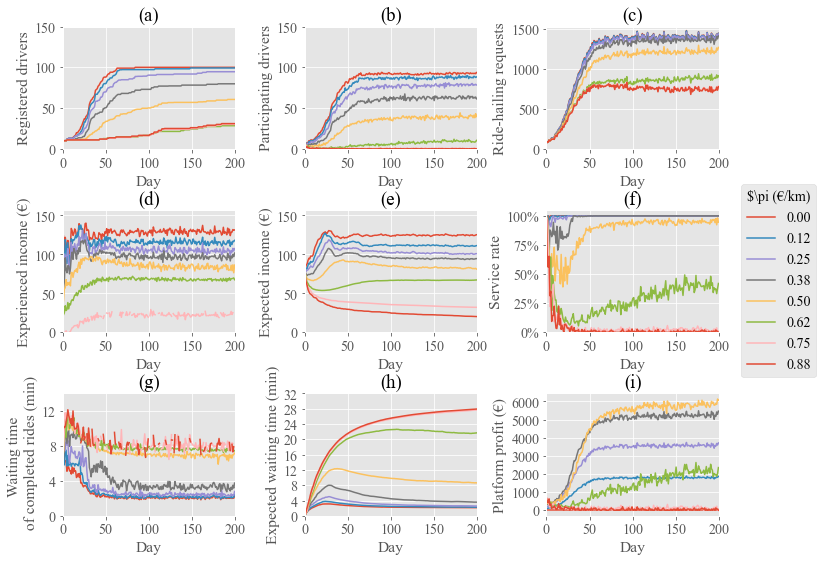

In [41]:
### KM FARE
# Creates four polar axes, and accesses them through the returned array
fig, axes = plt.subplots(3, 3, figsize = [12,9])
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.45, left=.14, right=.86, wspace=0.4)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# plt.setp(axes, xlim=[0,200])
# axes[0, 0].plot(res_scn.informed_drivers)
# # axes[0, 0].set_title()
# axes[0, 0].set_ylabel('Informed agents')
# axes[0, 0].set_xlabel('Day')
# axes[0, 0].set_title('(a)')
# axes[0, 0].set_ylim(bottom = 0, top = res_scn.informed_drivers.max().max() + 25)
# axes[0, 0].locator_params(axis='y', nbins=5)

plt.setp(axes, xlim=[0,200])
axes[0, 2].plot(res_scn.requests)
# axes[0, 0].set_title()
axes[0, 2].set_ylabel('Ride-hailing requests')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = 0, top = res_scn.requests.max().max() + 50)
# axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.requests.max().max()*1.2/50)*50+100)
axes[0, 2].locator_params(axis='y', nbins=5)

axes[0, 0].plot(res_scn.regist_drivers)
# axes[0, 0].set_title()
axes[0, 0].set_ylabel('Registered drivers')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.regist_drivers.max().max()/100)*100+50)
axes[0, 0].set_xlim(left = 0, right = 200)
axes[0, 0].locator_params(axis='y', nbins=5)
# axes[0, 0].plot(res_scn.informed_drivers)
# axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 1].plot(res_scn.particip_drivers)
axes[0, 1].set_ylabel('Participating drivers')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.particip_drivers.max().max()/100)*100+50)
axes[0, 1].set_xlim(left = 0, right = 200)
axes[0, 1].locator_params(axis='y', nbins=5)

# axes[1, 2].plot((res_scn.particip / res_scn.regist))
# axes[1, 2].set_ylabel('Participation rate')
# axes[1, 2].set_xlabel('Day')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# axes[1, 2].set_title('(f)')
# axes[1, 2].set_xlim(left = 0, right = 200)
# axes[1, 2].set_ylim(bottom = 0)
# axes[1, 2].locator_params(axis='y', nbins=5)

# axes[1, 0].plot((res_scn.mean_exp_inc_rel))
# axes[1, 0].set_ylabel('Rel. experienced inc.')
# axes[1, 0].set_xlabel('Day')
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel.max().max()*1.1/0.5)*0.5)
# axes[1, 0].locator_params(axis='y', nbins=5)
# axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# axes[1, 1].plot((res_scn.mean_exp_inc_rel_net))
# axes[1, 1].set_ylabel('Net rel. experienced inc.')
# axes[1, 1].set_xlabel('Day')
# axes[1, 1].set_title('(e)')
# axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_exp_inc_rel_net.max().max()*1.1/0.5)*0.5)
# axes[1, 1].locator_params(axis='y', nbins=5)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# axes[1, 2].plot((res_scn.mean_perc_inc))
# axes[1, 2].set_ylabel('Expected income')
# axes[1, 2].set_xlabel('day')
# axes[1, 2].set_title('(f)')

axes[2, 2].plot(res_scn.plf_profit)
axes[2, 2].set_ylabel('Platform profit (€)')
axes[2, 2].set_xlabel('Day')
axes[2, 2].set_xlim(left = 0, right = 200)
# axes[2, 2].set_ylim(bottom = 0)
axes[2, 2].set_title('(i)')
axes[2, 2].set_yticks(np.arange(0, math.ceil((res_scn.plf_profit).max().max()*1.1/1)*1+200, step=1000))

# axes[1, 2].plot((res_scn.regist / res_scn.inform))
# axes[1, 2].set_ylabel('Informed drivers \n with registration')
# axes[1, 2].set_xlabel('day')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
# axes[1, 2].set_title('(f)')

axes[2, 1].plot((res_scn.mean_wait_time/60))
axes[2, 1].set_ylabel('Expected waiting time (min)')
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_title('(h)')
axes[2, 1].set_ylim(bottom = 0, top = math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1)
axes[2, 1].set_yticks(np.arange(0, math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1+2, step=4))
axes[2, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

axes[2, 0].plot((res_scn.exp_pure_wait/60))
axes[2, 0].set_ylabel('Waiting time \n of completed rides (min)')
axes[2, 0].set_xlabel('Day')
axes[2, 0].set_title('(g)')
axes[2, 0].set_ylim(bottom = 0, top = math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1)
axes[2, 0].set_yticks(np.arange(0, math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1+0, step=4))
axes[2, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# axes[0, 2].plot(res_scn.mean_perc_inc_rel)
# axes[0, 2].set_ylabel('Rel. expected income')
# axes[0, 2].set_xlabel('Day')
# axes[0, 2].set_title('(c)')
# axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc_rel.max().max()*1.1/0.5)*0.5)
# axes[0, 2].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 1].plot(res_scn.mean_perc_inc)
axes[1, 1].set_ylabel('Expected income (€)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('(e)')
axes[1, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 0].plot(res_scn.mean_exp_inc)
axes[1, 0].set_ylabel('Experienced income (€)')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('(d)')
axes[1, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.2/0.5)*0.5)
axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[1, 0].locator_params(axis='y', nbins=4)

axes[1, 2].plot(res_scn.gets_offer / res_scn.requests)
axes[1, 2].set_ylabel('Service rate')
axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))  
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_title('(f)')
axes[1, 2].set_ylim(bottom = 0)
axes[1, 2].locator_params(axis='y', nbins=5)

# for scen in range(len(vals)):
#     axes[0, 2].hist(eql_scn_reg[scen].expected_income,bins = 100,density=True,alpha=0.3)
#     axes[0, 2].set_ylabel('Prob. density')
#     axes[0, 2].set_xlabel('Exp. income in equilibrium (€)')
#     axes[0, 2].set_title('(c)')
# #     axes[0, 2] = eql_scn_reg[scen].expected_income.plot(kind='density')
#     # plot_dens.set_xlim(0,math.ceil(eql_scn[scen].expected_income.max() / 25.0) * 25)
# axes[0, 2].set_xlim(0,150)

# axes[0, 2].plot(eql_scn_reg[scen].expected_income.plot(kind='density')
# axes[0, 2].set_ylabel('Expected income')
# axes[0, 2].set_xlabel('day')
# axes[0, 2].set_title('(c)')

# for i in range(len(vals)):
#     eql_scn_reg[i]['rel_perc_inc'] = eql_scn_reg[i].expected_income / params_scn[vals[i]]['drivers']['reservation_wage']
#     plot_dens = (eql_scn_reg[i].rel_perc_inc.plot(kind='density',ax=axes[0,1]))
# axes[0, 1].set_xlim(0.5,1.5)
# axes[0, 1].set_ylim(0, 8)
# # plt.locator_params(nbins=10)
# axes[0, 1].set_title('(b)')
# axes[0, 1].set_ylabel('Probability density')
# axes[0, 1].set_xlabel('Expected income / res. wage')

# for i in range(len(vals)):
#     plot_dens = (eql_scn_reg[i].res_wage.plot(kind='density',ax=axes[1,0]))
# axes[1, 0].set_xlim(0,120)
# axes[1, 0].set_ylim(0,0.06)
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylabel('Probability density')
# axes[1, 0].set_xlabel('Reservation wage')
# axes[1, 0].axvline(x=80,color = list(plt.rcParams['axes.prop_cycle'])[3]['color'],linestyle='--')
# axes[1, 0].set_xticks(np.arange(0, 160, step=40))

# labels = ['$\sigma_{W_d} =$' + '${}$'.format(str(s)) for s in vals]
# fig.legend(labels,loc='right',prop={'size': 11}) #bbox_to_anchor=(0.7, 0.5)
fig.legend([f'{i:.2f}' for i in vals],loc='right',title=(variable["sym"]+' (€/km)')) #bbox_to_anchor=(0.7, 0.5)
# fig.tight_layout()

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_six_fig.jpg'),dpi=300,bbox_inches='tight')

In [42]:
# ## COMMISSION
# # Creates four polar axes, and accesses them through the returned array
# fig, axes = plt.subplots(3, 3, figsize = [12,9])
# # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# # fig.subplots_adjust(hspace=.45, left=.14, right=.86, wspace=0.4)
# fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# plt.setp(axes, xlim=[0,200])
# axes[0, 2].plot(res_scn.requests)
# # axes[0, 0].set_title()
# axes[0, 2].set_ylabel('Ride-hailing requests')
# axes[0, 2].set_xlabel('Day')
# axes[0, 2].set_title('(c)')
# axes[0, 2].set_ylim(bottom = 0, top = res_scn.requests.max().max() + 50)
# # axes[0, 2].set_ylim(bottom = 0, top = math.ceil(res_scn.requests.max().max()*1.2/50)*50+100)
# axes[0, 2].locator_params(axis='y', nbins=5)

# axes[0, 0].plot(res_scn.regist_drivers)
# # axes[0, 0].set_title()
# axes[0, 0].set_ylabel('Registered drivers')
# axes[0, 0].set_xlabel('Day')
# axes[0, 0].set_title('(a)')
# axes[0, 0].set_ylim(bottom = 0, top = math.ceil(res_scn.regist_drivers.max().max()/100)*100+25)
# axes[0, 0].set_xlim(left = 0, right = 200)
# axes[0, 0].locator_params(axis='y', nbins=5)
# # axes[0, 0].plot(res_scn.informed_drivers)
# # axes[0, 1].locator_params(axis='y', nbins=5)

# axes[0, 1].plot(res_scn.particip_drivers)
# axes[0, 1].set_ylabel('Participating drivers')
# axes[0, 1].set_xlabel('Day')
# axes[0, 1].set_title('(b)')
# axes[0, 1].set_ylim(bottom = 0, top = math.ceil(res_scn.particip_drivers.max().max()/100)*100+25)
# axes[0, 1].set_xlim(left = 0, right = 200)
# axes[0, 1].locator_params(axis='y', nbins=5)

# axes[2, 2].plot(res_scn.plf_profit)
# axes[2, 2].set_ylabel('Platform profit (€)')
# axes[2, 2].set_xlabel('Day')
# axes[2, 2].set_xlim(left = 0, right = 200)
# # axes[2, 2].set_ylim(bottom = 0)
# axes[2, 2].set_title('(i)')
# axes[2, 2].set_yticks(np.arange(0, math.ceil((res_scn.plf_profit).max().max()*1.1/1)*1+200, step=1000))

# axes[2, 1].plot((res_scn.mean_wait_time/60))
# axes[2, 1].set_ylabel('Expected waiting time (min)')
# axes[2, 1].set_xlabel('Day')
# axes[2, 1].set_title('(h)')
# axes[2, 1].set_ylim(bottom = 0, top = math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1)
# axes[2, 1].set_yticks(np.arange(0, math.ceil((res_scn.mean_wait_time/60).max().max()*1.1/1)*1+2, step=4))
# axes[2, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# axes[2, 0].plot((res_scn.exp_pure_wait/60))
# axes[2, 0].set_ylabel('Waiting time \n of completed rides (min)')
# axes[2, 0].set_xlabel('Day')
# axes[2, 0].set_title('(g)')
# axes[2, 0].set_ylim(bottom = 0, top = math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1)
# axes[2, 0].set_yticks(np.arange(0, math.ceil((res_scn.exp_pure_wait/60).max().max()*1.1/1)*1+2, step=4))
# axes[2, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# axes[1, 1].plot(res_scn.mean_perc_inc)
# axes[1, 1].set_ylabel('Expected income (€)')
# axes[1, 1].set_xlabel('Day')
# axes[1, 1].set_title('(e)')
# axes[1, 1].set_ylim(bottom = -50, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.1/0.5)*0.5)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[1, 1].locator_params(axis='y', nbins=5)

# axes[1, 0].plot(res_scn.mean_exp_inc)
# axes[1, 0].set_ylabel('Experienced income (€)')
# axes[1, 0].set_xlabel('Day')
# axes[1, 0].set_title('(d)')
# axes[1, 0].set_ylim(bottom = -50, top = math.ceil(res_scn.mean_perc_inc.max().max()*1.1/0.5)*0.5)
# axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[1, 0].locator_params(axis='y', nbins=4)

# axes[1, 2].plot(res_scn.gets_offer / res_scn.requests)
# axes[1, 2].set_ylabel('Service rate')
# axes[1, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))  
# axes[1, 2].set_xlabel('Day')
# axes[1, 2].set_title('(f)')
# axes[1, 2].set_ylim(bottom = 0)
# axes[1, 2].locator_params(axis='y', nbins=5)

# fig.legend([f'{i*100:.1f}%' for i in vals],loc='right',title=variable["sym"]) #bbox_to_anchor=(0.7, 0.5)
# # fig.tight_layout()

# fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_six_fig.jpg'),dpi=300,bbox_inches='tight')

In [43]:
# overall = pd.DataFrame()
# overall['regist_mean'] = d2d.regist.mean(axis=1)
# overall['regist_std'] = d2d.regist.std(axis=1)
# overall['particip_mean'] = d2d.particip.mean(axis=1)
# overall['particip_std'] = d2d.particip.std(axis=1)
# overall['perc_inc_mean'] = d2d.mean_perc_inc.mean(axis=1)
# overall['perc_inc_std'] = d2d.mean_perc_inc.std(axis=1)
# overall['exp_inc_mean'] = d2d.mean_exp_inc.mean(axis=1)
# overall['exp_inc_std'] = d2d.mean_exp_inc.std(axis=1)

In [44]:
plf[0][0]

,nRIDES,nREJECTED,DRIVING_TIME,DRIVING_DIST,REVENUE,COST,NET_INCOME,OUT,STARTS_DAY,OPENS_APP,...,ARRIVES_AT_PICKUP,MEETS_TRAVELLER_AT_PICKUP,DEPARTS_FROM_PICKUP,ARRIVES_AT_DROPOFF,CONTINUES_SHIFT,STARTS_REPOSITIONING,REPOSITIONED,DECIDES_NOT_TO_DRIVE,ENDS_SHIFT,nV
sum,75.000000,0.0,72806.000000,728.060000,773.640000,182.015000,591.625000,93.000000,0.0,15111.000000,...,5.00,2250.000000,44258.000000,159201.000000,0.0,0.0,0.0,0.0,0.0,100
mean,0.750000,0.0,728.060000,7.280600,7.736400,1.820150,5.916250,0.930000,0.0,151.110000,...,0.05,22.500000,442.580000,1592.010000,0.0,0.0,0.0,0.0,0.0,100
std,2.822618,0.0,2730.929596,27.309296,29.016463,6.827324,22.196477,0.256432,0.0,854.654327,...,0.50,84.678537,1659.363631,5849.636068,0.0,0.0,0.0,0.0,0.0,100


In [45]:
# kpi_table = pd.DataFrame()
# for kpi in kpis:
#     kpi_table[kpi] = res_scn[kpi].iloc[len(res_scn[kpi])-1]
# kpi_table['service_rate'] = (1 - kpi_table.perc_pax_reject) * 100
# kpi_table['cum_profit'] = res_scn.plf_profit.sum() / 1000000
# kpi_table['std_perc_inc'] = std_perc_inc
# kpi_table['std_exp_inc'] = std_exp_inc
# kpi_table.inform = round(kpi_table.inform).astype(int)
# kpi_table.regist = round(kpi_table.regist).astype(int)
# kpi_table.particip = round(kpi_table.particip).astype(int)
# kpi_table.mean_perc_inc = round(kpi_table.mean_perc_inc,2)
# kpi_table.std_perc_inc = round(kpi_table.std_perc_inc,2)
# kpi_table.mean_exp_inc = round(kpi_table.mean_exp_inc,2)
# kpi_table.std_exp_inc = round(kpi_table.std_exp_inc,2)
# kpi_table.service_rate = round(kpi_table.service_rate,1)
# kpi_table.pax_wait_time = round(kpi_table.pax_wait_time,1)
# kpi_table.plf_profit = round(kpi_table.plf_profit).astype(int)
# kpi_table = kpi_table.drop(['perc_pax_reject'],axis=1)
# kpi_table = kpi_table[['inform','regist','particip','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','pax_wait_time','plf_profit']]
# kpi_table = kpi_table
# # output = kpi_table.to_string(formatters={
# #     vals[0]: '{:,.2f}'.format,
# #     vals[1]: '{:,.2f}'.format,
# #     vals[2]: '{:,.2f}'.format,
# #     vals[3]: '{:,.2f}'.format,
# #     vals[4]: '{:,.2f}'.format
# # })
# print(kpi_table.to_latex(index=True))

In [46]:
kpi_table = DotMap()
for j in range(5): # Number of days considered as equilibrium
    kpi_table[j] = pd.DataFrame()
    for kpi in kpis:
        kpi_table[j][kpi] = res_scn[kpi].iloc[len(res_scn[kpi])-j-1]
    kpi_table[j]['service_rate'] = (kpi_table[j].gets_offer / kpi_table[j].requests) * 100
    kpi_table[j]['cum_profit'] = res_scn.plf_profit.sum() / 1000000
    kpi_table[j]['std_perc_inc'] = std_perc_inc
    kpi_table[j]['std_exp_inc'] = std_exp_inc
    kpi_table[j]['std_perc_wait'] = std_perc_wait
    kpi_table[j]['std_exp_wait'] = std_exp_wait
    kpi_table[j]['std_corr_exp_wait'] = std_corr_exp_wait
    # output = kpi_table.to_string(formatters={
    #     vals[0]: '{:,.2f}'.format,
    #     vals[1]: '{:,.2f}'.format,
    #     vals[2]: '{:,.2f}'.format,
    #     vals[3]: '{:,.2f}'.format,
    #     vals[4]: '{:,.2f}'.format
    # })
#     print(kpi_table.to_latex(index=True))

kpi_eq = pd.concat([kpi_table[0], kpi_table[1], kpi_table[2], kpi_table[3], kpi_table[4]]).groupby(level=0).mean()
kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
kpi_eq.requests = round(kpi_eq.requests).astype(int)
kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
kpi_eq.service_rate = round(kpi_eq.service_rate,1)
kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]
kpi_eq = kpi_eq

# kpi_eq = sum([kpi_table[0],kpi_table[1]])
# kpi_eq = sum([[kpi_table[j]] for j in range(5)])
print(kpi_eq.astype('str').T.to_latex(index=True))
    

\begin{tabular}{lllllllll}
\toprule
{} &   0.000 &   0.125 &   0.250 &  0.375 &  0.500 &  0.625 &  0.750 &   0.875 \\
\midrule
informed\_drivers  &     100 &     100 &     100 &    100 &    100 &    100 &    100 &     100 \\
regist\_drivers    &     100 &      99 &      95 &     80 &     61 &     28 &     30 &      31 \\
particip\_drivers  &      93 &      88 &      79 &     63 &     40 &      9 &      0 &       0 \\
requests          &    1422 &    1419 &    1411 &   1382 &   1239 &    901 &    755 &     750 \\
mean\_perc\_inc     &  124.61 &  110.84 &  100.57 &  94.26 &  81.73 &  67.06 &  32.17 &   20.37 \\
std\_perc\_inc      &   23.31 &   19.35 &   15.38 &  10.31 &   2.98 &   1.66 &   4.46 &    8.48 \\
mean\_exp\_inc      &   130.3 &  116.01 &  105.46 &  98.47 &  82.93 &  68.85 &  25.58 &  -22.82 \\
std\_exp\_inc       &   41.39 &   34.79 &   28.83 &  14.51 &    7.1 &   3.29 &    nan &     nan \\
service\_rate      &   100.0 &   100.0 &   100.0 &  100.0 &   95.4 &   37.3 &    1.8 &

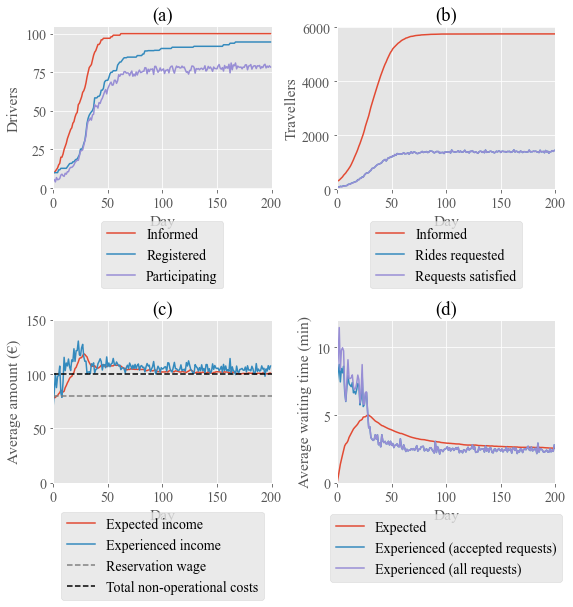

In [61]:
# Creates four polar axes, and accesses them through the returned array
fig, axes = plt.subplots(2, 2, figsize = [9,8.4])
# fig, axes = plt.subplots(1, 4, figsize = [12,3])
fig.subplots_adjust(hspace=0.8, wspace=0.3)
# fig.subplots_adjust(hspace=0.45, wspace=0.35)

# for ax in axes:
#     ax.set_xlabel('days')
if variable["name"] == 'res_wage':
    value = 80
    num = 3
elif variable["name"] == 'driver_pool':
    value = 1000
    num = 4
elif variable["name"] == 'comm_rate':
    value = 0.25
    num = 2
elif variable["name"] == 'reg_costs':
    value = 20
    num = 2
elif variable["name"] == 'het_res_wage':
    value = 0
    num = 0
elif variable["name"] == 'ptcp_beta':
    value = 1
    num = 4
elif variable["name"] == 'full_case':
    value = 10000
    num = 0
elif variable["name"] == 'nP':
    value = 10000
    num = 0

axes[0,0].plot(res_scn.informed_drivers[value])
axes[0,0].plot(res_scn.regist_drivers[value])
axes[0,0].plot(res_scn.particip_drivers[value])
# axes[0,0].plot(res_scn.informed_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[2]['color'])
# axes[0,0].plot(res_scn.regist_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[4]['color'])
# axes[0,0].plot(res_scn.particip_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[5]['color'])
# axes[0].legend(["Informed","Registered", "Participating"],loc="below")
axes[0,0].legend(["Informed","Registered", "Participating"],loc='lower center', bbox_to_anchor=(0.5, -0.65),fontsize=14)
axes[0,0].set_ylabel('Drivers')
axes[0,0].set_xlabel('Day')
axes[0,0].set_title('(a)')
# axes[0].set_ylim(bottom = 0, top = params[0]['nV']*1.1)
axes[0,0].set_xlim(left = 0, right = 200)

axes[1,0].plot(res_scn.mean_perc_inc[value])
axes[1,0].plot(res_scn.mean_exp_inc[value])
axes[1,0].axhline(y=80,color='gray',linestyle='--')
axes[1,0].axhline(y=100,color='black',linestyle='--')
# axes[0, 1].axhline(y=params[scn_id]['drivers']['reservation_wage'],color='gray',linestyle='--')
axes[1,0].legend(["Expected income","Experienced income","Reservation wage","Total non-operational costs"], loc='lower center', bbox_to_anchor=(0.5, -0.76),fontsize=14)
axes[1,0].set_xlabel('Day')
axes[1,0].set_title('(c)')
axes[1,0].set_ylabel('Average amount (€)')
axes[1,0].set_ylim(bottom = 0, top = 150)
axes[1,0].set_xlim(left = 0, right = 200)
axes[1,0].locator_params(axis='y', nbins=4)

axes[1,1].plot(res_scn.mean_wait_time[value]/60)
axes[1,1].plot(res_scn.exp_pure_wait[value]/60)
axes[1,1].plot(res_scn.exp_wait_time[value]/60)
axes[1,1].legend(["Expected","Experienced (accepted requests)","Experienced (all requests)"], loc='lower center', bbox_to_anchor=(0.5, -0.65),fontsize=14)
axes[1,1].set_xlabel('Day')
axes[1,1].set_title('(d)')
axes[1,1].set_ylabel('Average waiting time (min)')
axes[1,1].set_ylim(bottom = 0)
axes[1,1].set_xlim(left = 0, right = 200)
axes[1,1].locator_params(axis='y', nbins=4)

axes[0,1].plot(res_scn.informed_travs[value])
axes[0,1].plot(res_scn.requests[value])
axes[0,1].plot(res_scn.gets_offer[value])
axes[0,1].legend(["Informed","Rides requested","Requests satisfied"], loc='lower center', bbox_to_anchor=(0.5, -0.65),fontsize=14)
axes[0,1].set_xlabel('Day')
axes[0,1].set_title('(b)')
axes[0,1].set_ylabel('Travellers')
axes[0,1].set_ylim(bottom = 0)
axes[0,1].set_xlim(left = 0, right = 200)
axes[0,1].locator_params(axis='y', nbins=4)


# particip_drivers = eql_scn[num][eql_scn[num].event != "driverEvent.DECIDES_NOT_TO_DRIVE"]

# axes[2] = eql_scn[num].expected_income.plot(kind='density',color=list(plt.rcParams['axes.prop_cycle'])[4]['color'])
# axes[2] = particip_drivers.expected_income.plot(kind='density',color=list(plt.rcParams['axes.prop_cycle'])[5]['color'])
# axes[2].set_xlim(40,120)
# axes[2].set_xlabel('Expected income (€)')
# axes[2].axvline(x=80,color = list(plt.rcParams['axes.prop_cycle'])[3]['color'],linestyle='--')
# axes[2].legend(["Registered","Participating","Reservation wage"], loc='lower center', bbox_to_anchor=(0.5, -0.7),fontsize = 12)
# axes[2].set_title('(c)')
# axes[2].axvline(x=params_scn[vals[scen]]['drivers']['reservation_wage'],color='grey',linestyle='--')




fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

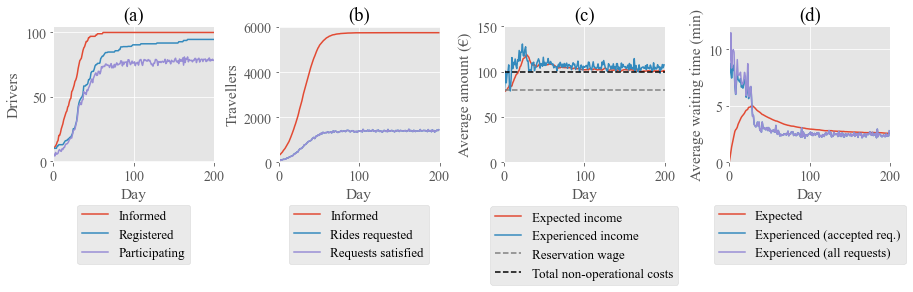

In [80]:
# Creates four polar axes, and accesses them through the returned array
fig, axes = plt.subplots(1, 4, figsize = [15,2.5])
# fig, axes = plt.subplots(1, 4, figsize = [12,3])
fig.subplots_adjust(wspace=0.4)
# fig.subplots_adjust(hspace=0.45, wspace=0.35)

# for ax in axes:
#     ax.set_xlabel('days')
if variable["name"] == 'res_wage':
    value = 80
    num = 3
elif variable["name"] == 'driver_pool':
    value = 1000
    num = 4
elif variable["name"] == 'comm_rate':
    value = 0.25
    num = 2
elif variable["name"] == 'reg_costs':
    value = 20
    num = 2
elif variable["name"] == 'het_res_wage':
    value = 0
    num = 0
elif variable["name"] == 'ptcp_beta':
    value = 1
    num = 4
elif variable["name"] == 'full_case':
    value = 10000
    num = 0
elif variable["name"] == 'nP':
    value = 10000
    num = 0

axes[0].plot(res_scn.informed_drivers[value])
axes[0].plot(res_scn.regist_drivers[value])
axes[0].plot(res_scn.particip_drivers[value])
# axes[0,0].plot(res_scn.informed_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[2]['color'])
# axes[0,0].plot(res_scn.regist_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[4]['color'])
# axes[0,0].plot(res_scn.particip_drivers[value], color=list(plt.rcParams['axes.prop_cycle'])[5]['color'])
# axes[0].legend(["Informed","Registered", "Participating"],loc="below")
axes[0].legend(["Informed","Registered", "Participating"],loc='lower center', bbox_to_anchor=(0.5, -0.8),fontsize=13)
axes[0].set_ylabel('Drivers')
axes[0].set_xlabel('Day')
axes[0].set_title('(a)')
# axes[0].set_ylim(bottom = 0, top = params[0]['nV']*1.1)
axes[0].set_xlim(left = 0, right = 200)

axes[2].plot(res_scn.mean_perc_inc[value])
axes[2].plot(res_scn.mean_exp_inc[value])
axes[2].axhline(y=80,color='gray',linestyle='--')
axes[2].axhline(y=100,color='black',linestyle='--')
# axes[0, 1].axhline(y=params[scn_id]['drivers']['reservation_wage'],color='gray',linestyle='--')
axes[2].legend(["Expected income","Experienced income","Reservation wage","Total non-operational costs"], loc='lower center', bbox_to_anchor=(0.5, -0.95),fontsize=13)
axes[2].set_xlabel('Day')
axes[2].set_title('(c)')
axes[2].set_ylabel('Average amount (€)')
axes[2].set_ylim(bottom = 0, top = 150)
axes[2].set_xlim(left = 0, right = 200)
axes[2].locator_params(axis='y', nbins=4)

axes[3].plot(res_scn.mean_wait_time[value]/60)
axes[3].plot(res_scn.exp_pure_wait[value]/60)
axes[3].plot(res_scn.exp_wait_time[value]/60)
axes[3].legend(["Expected","Experienced (accepted req.)","Experienced (all requests)"], loc='lower center', bbox_to_anchor=(0.5, -0.8),fontsize=13)
axes[3].set_xlabel('Day')
axes[3].set_title('(d)')
axes[3].set_ylabel('Average waiting time (min)')
axes[3].set_ylim(bottom = 0)
axes[3].set_xlim(left = 0, right = 200)
axes[3].locator_params(axis='y', nbins=4)

axes[1].plot(res_scn.informed_travs[value])
axes[1].plot(res_scn.requests[value])
axes[1].plot(res_scn.gets_offer[value])
axes[1].legend(["Informed","Rides requested","Requests satisfied"], loc='lower center', bbox_to_anchor=(0.5, -0.8),fontsize=13)
axes[1].set_xlabel('Day')
axes[1].set_title('(b)')
axes[1].set_ylabel('Travellers')
axes[1].set_ylim(bottom = 0)
axes[1].set_xlim(left = 0, right = 200)
axes[1].locator_params(axis='y', nbins=4)


# particip_drivers = eql_scn[num][eql_scn[num].event != "driverEvent.DECIDES_NOT_TO_DRIVE"]

# axes[2] = eql_scn[num].expected_income.plot(kind='density',color=list(plt.rcParams['axes.prop_cycle'])[4]['color'])
# axes[2] = particip_drivers.expected_income.plot(kind='density',color=list(plt.rcParams['axes.prop_cycle'])[5]['color'])
# axes[2].set_xlim(40,120)
# axes[2].set_xlabel('Expected income (€)')
# axes[2].axvline(x=80,color = list(plt.rcParams['axes.prop_cycle'])[3]['color'],linestyle='--')
# axes[2].legend(["Registered","Participating","Reservation wage"], loc='lower center', bbox_to_anchor=(0.5, -0.7),fontsize = 12)
# axes[2].set_title('(c)')
# axes[2].axvline(x=params_scn[vals[scen]]['drivers']['reservation_wage'],color='grey',linestyle='--')




fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

In [48]:
res_scn['mean_exp_inc'].head(5)

,0.000,0.125,0.250,0.375,0.500,0.625,0.750,0.875
day,,,,,,,,
0,101.590388,84.011524,70.636875,54.452007,33.908088,19.102208,1.425488,-17.113488
1,124.041542,102.613366,83.788125,54.415143,40.670095,22.670988,1.177892,-27.756289
2,100.319167,83.861033,100.446946,66.248247,56.088750,25.113892,-0.716667,-30.060547
3,121.974704,118.825287,87.605710,95.623469,57.008685,34.099969,-0.556562,-31.632104
4,114.607972,111.087315,97.834026,80.582487,67.635500,27.977945,2.027188,-32.238984


In [49]:
res_scn.particip.head(5)

TypeError: 'DotMap' object is not callable

In [ ]:
res_scn.mean_exp_inc_rel_net.head(5)

In [ ]:
trav_eql[0]

In [ ]:
d2d_pax[0]

In [ ]:
res_scn.plf_profit

In [ ]:
d2d_plf[0]

In [ ]:
res_scn.mean_wait_time.head(50)

In [ ]:
res_scn.exp_wait_time.head(50)

In [ ]:
res_scn.exp_pure_wait.head(50)

In [ ]:
trav_eql[0].head(50)

In [ ]:
kpi_table

In [ ]:
driver_eql[24]